# Proprietà di scaling

Esercizio 1 - Gaussiana

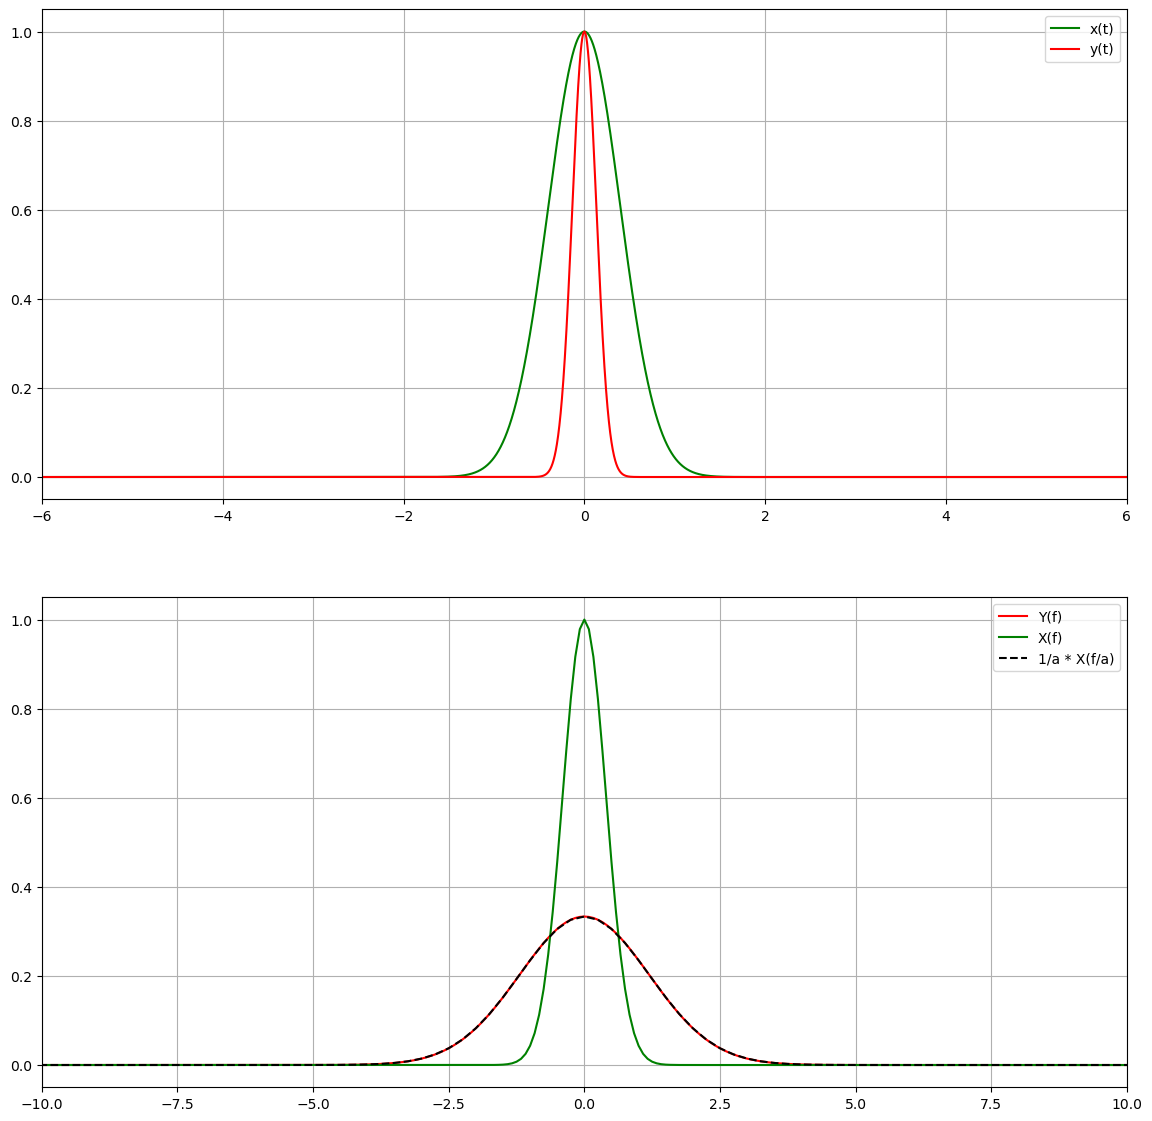

In [2]:
import matplotlib.pyplot as plt
import numpy as np

dt = 0.002
t = np.arange(-6, 6 + dt, dt)
N = len(t)
a = 3

freq = np.fft.fftshift(np.fft.fftfreq(N, dt))
x_t = np.exp(-np.pi * t **2)
y_t = np.exp(-np.pi * (a*t) **2)

X = np.fft.fftshift(np.fft.fft(x_t)) * dt
Y = np.fft.fftshift(np.fft.fft(y_t)) * dt

plt.figure(figsize=(14, 14))
plt.subplot(2, 1, 1)
plt.plot(t, x_t, color="green", label="x(t)")
plt.plot(t, y_t, color="red", label="y(t)")
plt.xlim(-6, 6)
plt.legend()
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(freq, np.abs(Y), color="red", label="Y(f)")
plt.plot(freq, np.abs(X), color="green", label="X(f)")
plt.plot(freq*a, np.abs(X)/a, color="black", linestyle="--", label="1/a * X(f/a)")
plt.xlim(-10, 10)
plt.legend()
plt.grid()
plt.show()

Esercizio 2 - Rettangolo

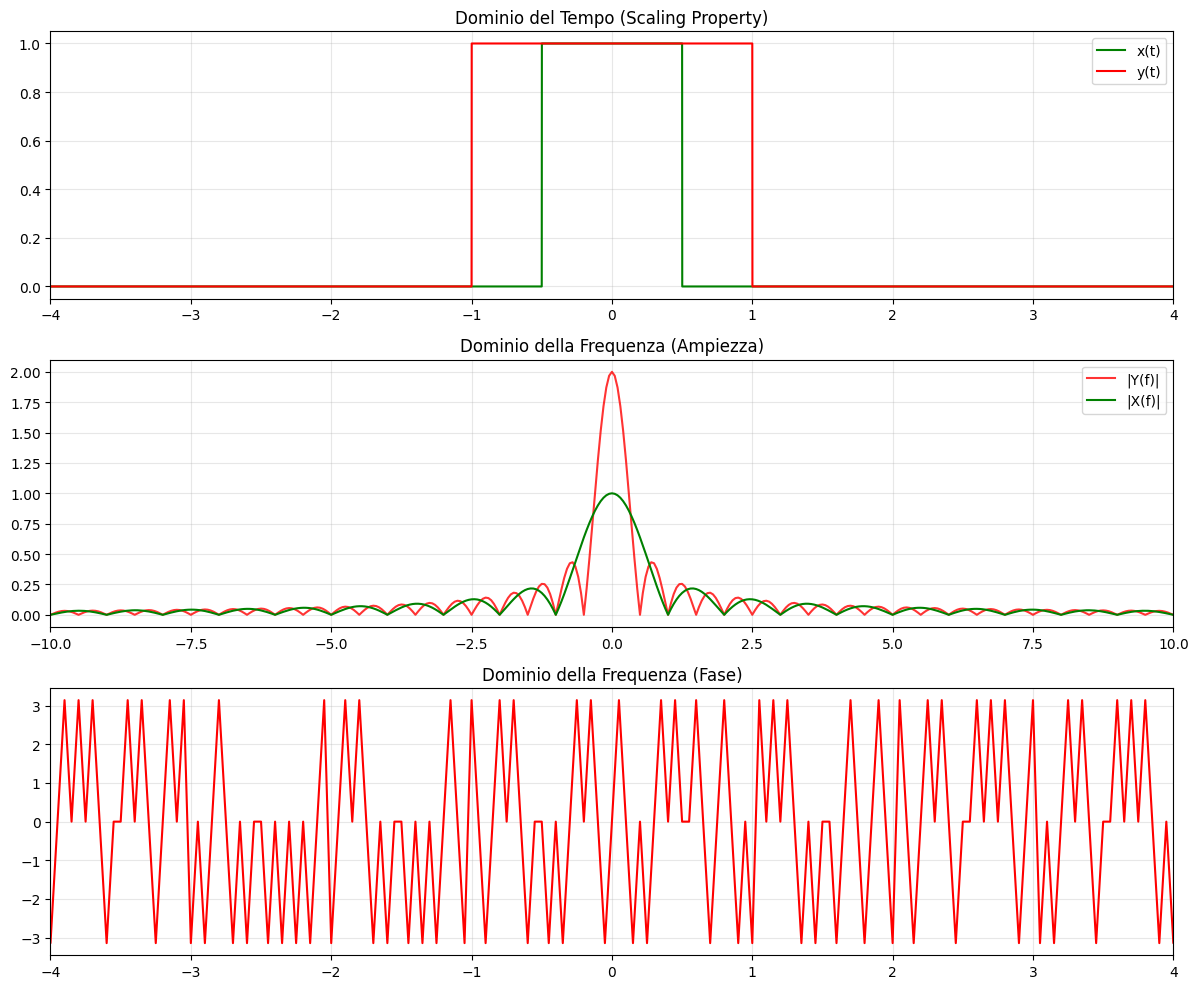

In [12]:
import numpy as np
import matplotlib.pyplot as plt

dt = 0.001
t = np.arange(-10, 10 + dt, dt) # Intervallo più ampio = FFT più fluida
N = len(t)
T = 1
a = 0.5

x_t = np.where(np.abs(t) <= T/2, 1, 0)
y_t = np.where(np.abs(a * t) <= T/2, 1, 0)

X = np.fft.fftshift(np.fft.fft(x_t)) * dt
Y = np.fft.fftshift(np.fft.fft(y_t)) * dt
freq = np.fft.fftshift(np.fft.fftfreq(N, dt))

plt.figure(figsize=(12, 10))

plt.subplot(3, 1, 1)
plt.plot(t, x_t, color="green", label="x(t)", linewidth=1.5)
plt.plot(t, y_t, color="red", label="y(t)", linewidth=1.5)
plt.title("Dominio del Tempo (Scaling Property)")
plt.xlim(-4, 4)
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(3, 1, 2)
plt.plot(freq, np.abs(Y), color="red", label="|Y(f)|", alpha=0.8)
plt.plot(freq, np.abs(X), color="green", label="|X(f)|", linestyle="-")
#plt.plot(freq, (1/a) * np.abs(np.sinc(freq/a * T)), color="black", linestyle=":", label="Teorico: 1/|a| * X(f/a)")
plt.xlim(-10, 10)
plt.title("Dominio della Frequenza (Ampiezza)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(3, 1, 3)
plt.plot(freq, np.angle(Y), color="red", label="Fase Y(f)")
plt.xlim(-4, 4)
plt.title("Dominio della Frequenza (Fase)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Esercizio 3 - Esponenziale 

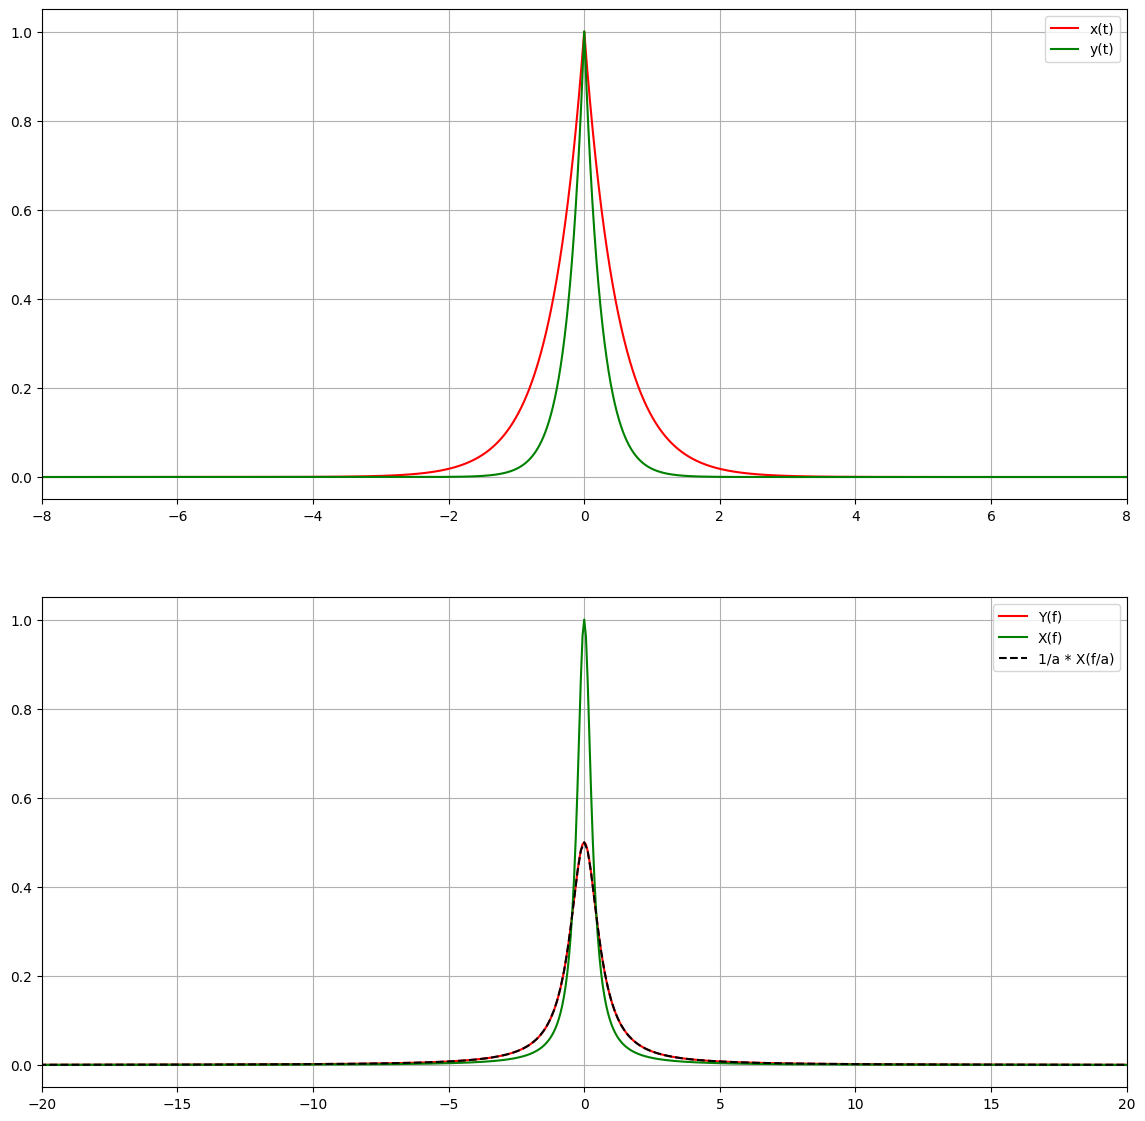

In [3]:
dt = 0.002
t = np.arange(-8, 8 + dt, dt)
N = len(t)
a = 2

freq = np.fft.fftshift(np.fft.fftfreq(N, dt))
x_t = np.exp(-2 * np.abs(t))
y_t = np.exp(-2 * np.abs(a*t))

X = np.fft.fftshift(np.fft.fft(x_t)) * dt
Y = np.fft.fftshift(np.fft.fft(y_t)) * dt

plt.figure(figsize=(14, 14))
plt.subplot(2, 1, 1)
plt.plot(t, x_t, color="red", label="x(t)")
plt.plot(t, y_t, color="green", label="y(t)")
plt.xlim(-8, 8)
plt.legend()
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(freq, np.abs(Y), color="red", label="Y(f)")
plt.plot(freq, np.abs(X), color="green", label="X(f)")
plt.plot(freq*a, np.abs(X)/a, color="black", linestyle="--", label="1/a * X(f/a)")
plt.xlim(-20, 20)
plt.legend()
plt.grid()
plt.show()

Esercizio 4 - Coseno

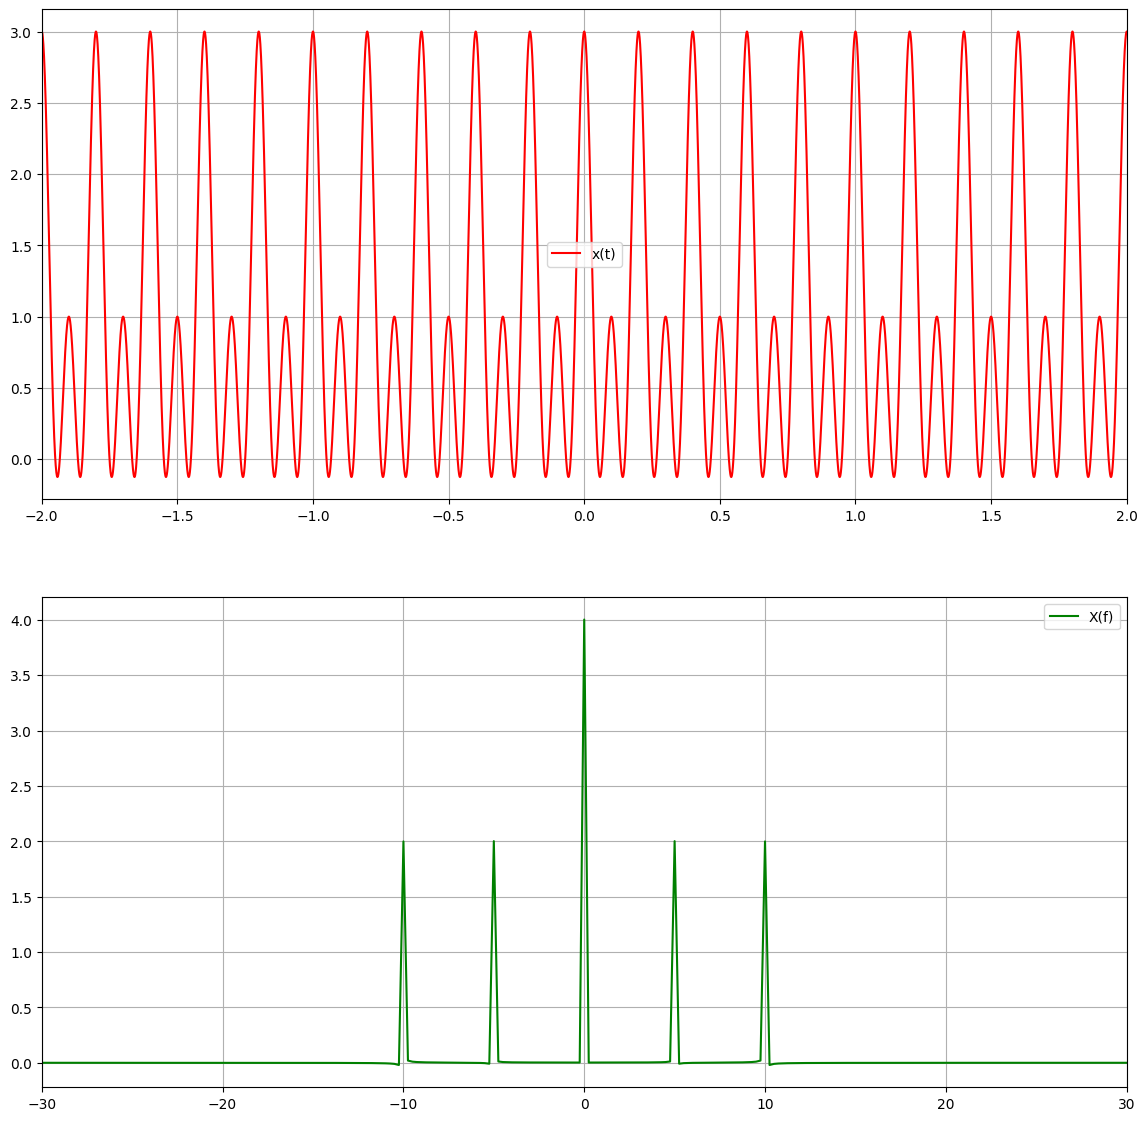

In [4]:
dt = 0.0005
t = np.arange(-2, 2 + dt, dt)
N = len(t)
f0 = 5 
a = 4

freq = np.fft.fftshift(np.fft.fftfreq(N, dt))
x_t = np.cos(2 * np.pi * f0 * t ) + np.cos(2 * np.pi * 2 * f0 * t) + np.cos(2 * np.pi )
y_t = np.cos(2 * np.pi * f0 * t * a)

X = np.fft.fftshift(np.fft.fft(x_t)) * dt
Y = np.fft.fftshift(np.fft.fft(y_t)) * dt

plt.figure(figsize=(14, 14))
plt.subplot(2, 1, 1)
plt.plot(t, x_t, color="red", label="x(t)")
#plt.plot(t, y_t, color="green", label="y(t)")
plt.xlim(-2, 2)
plt.legend()
plt.grid()
plt.subplot(2, 1, 2)
#plt.plot(freq, np.real(Y), color="red", label="Y(f)")
plt.plot(freq, np.real(X), color="green", label="X(f)")
#plt.plot(freq*a, np.real(X)/a, color="black", linestyle="--", label="1/a * X(f/a)")
plt.xlim(-30, 30)
plt.legend()
plt.grid()
plt.show()

Esercizio 5 - Triangolo

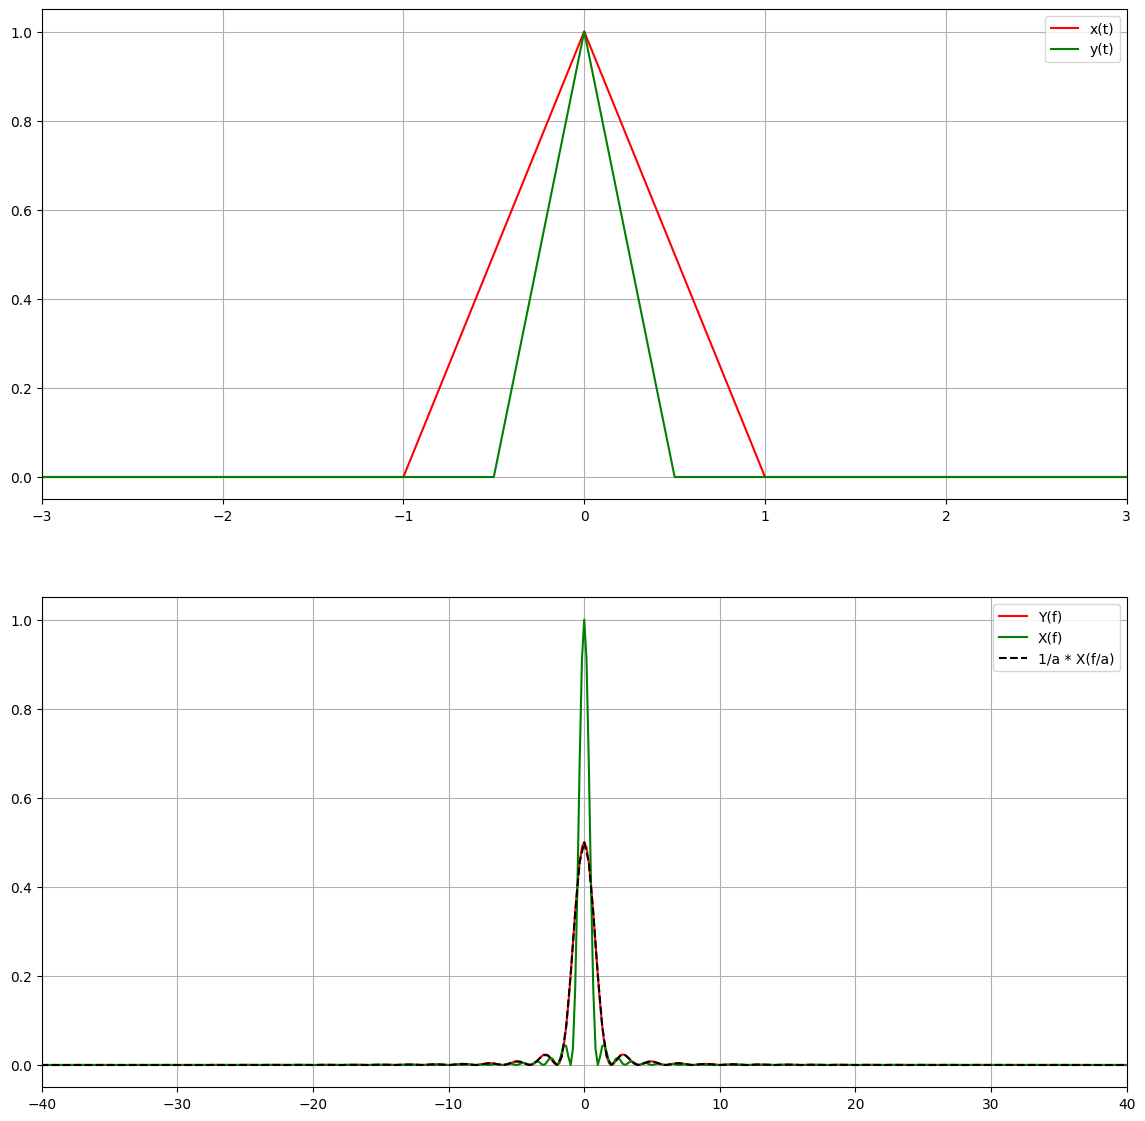

In [5]:
dt = 0.001
t = np.arange(-3, 3 + dt, dt)
N = len(t)
T = 1
a = -2

freq = np.fft.fftshift(np.fft.fftfreq(N, dt))
x_t = np.piecewise(t, [np.abs(t) <= T, np.abs(t) > T], 
                   [lambda x: 1 - np.abs(x/T), 0])

y_t = np.piecewise(t, [np.abs(t*a) <= T, np.abs(t*a) > T], 
                   [lambda x: 1 - np.abs(x*a/T), 0])

X = np.fft.fftshift(np.fft.fft(x_t)) * dt
Y = np.fft.fftshift(np.fft.fft(y_t)) * dt

plt.figure(figsize=(14, 14))
plt.subplot(2, 1, 1)
plt.plot(t, x_t, color="red", label="x(t)")
plt.plot(t, y_t, color="green", label="y(t)")
plt.xlim(-3, 3)
plt.legend()
plt.grid()
plt.subplot(2, 1, 2)
plt.plot(freq, np.abs(Y), color="red", label="Y(f)")
plt.plot(freq, np.abs(X), color="green", label="X(f)")
plt.plot(freq*a, np.abs(X)/np.abs(a), color="black", linestyle="--", label="1/a * X(f/a)")
plt.xlim(-40, 40)
plt.legend()
plt.grid()
plt.show()

Esercizio 6 - Rettangolo * Rettangolo

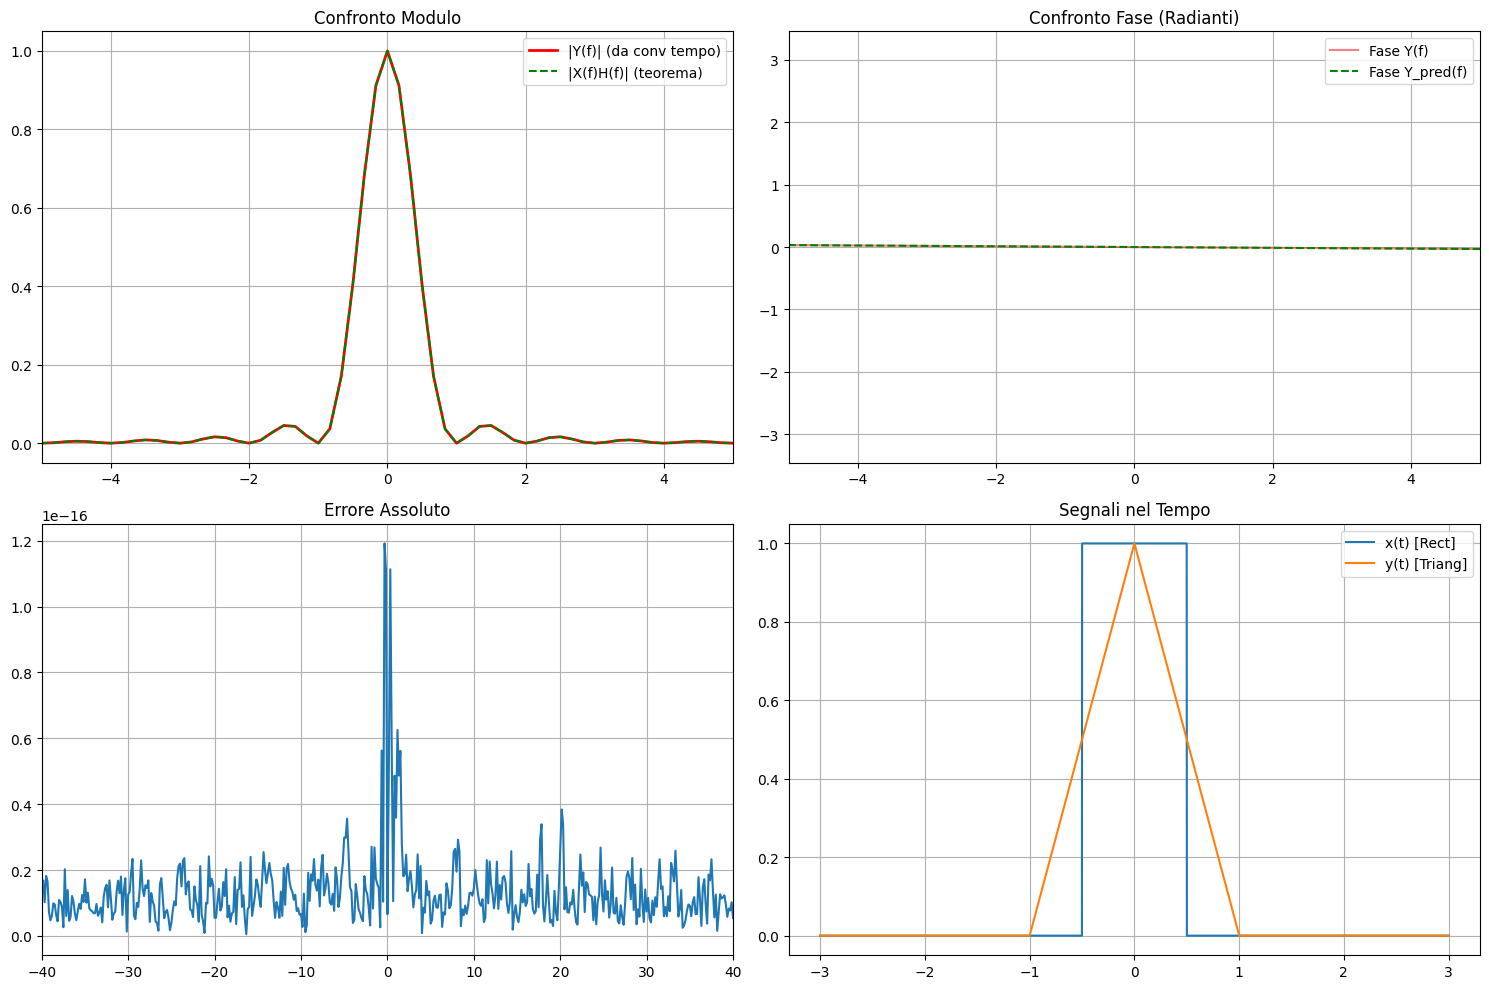

Errore relativo totale: 5.112046120457362e-16


In [6]:
dt = 0.001
t = np.arange(-3, 3 + dt, dt)
N = len(t)
T = 1

x_t = np.piecewise(t, [np.abs(t) <= T/2, np.abs(t) > T/2], [1, 0])
h_t = np.piecewise(t, [np.abs(t) <= T/2, np.abs(t) > T/2], [1, 0])

y_t = np.convolve(x_t, h_t, mode="same") * dt

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x_t))) * dt
H = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(h_t))) * dt
freq = np.fft.fftshift(np.fft.fftfreq(N, dt))

Y_pred = X * H # Prodotto delle trasformate
Y = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(y_t))) * dt

fig, ax = plt.subplots(2, 2, figsize=(15, 10))

#modulo
ax[0, 0].plot(freq, np.abs(Y), 'r', label='|Y(f)| (da conv tempo)', linewidth=2)
ax[0, 0].plot(freq, np.abs(Y_pred), 'g--', label='|X(f)H(f)| (teorema)')
ax[0, 0].set_xlim(-5, 5) # Zoom per vedere bene i lobi del Sinc
ax[0, 0].set_title("Confronto Modulo")
ax[0, 0].legend()
ax[0, 0].grid()

#fase
ax[0, 1].plot(freq, np.angle(Y), 'r', label='Fase Y(f)', alpha=0.5)
ax[0, 1].plot(freq, np.angle(Y_pred), 'g--', label='Fase Y_pred(f)')
ax[0, 1].set_xlim(-5, 5)
ax[0, 1].set_title("Confronto Fase (Radianti)")
ax[0, 1].legend()
ax[0, 1].grid()

#errore
ax[1, 0].plot(freq, np.abs(Y - Y_pred))
ax[1, 0].set_xlim(-40, 40)
ax[1, 0].set_title("Errore Assoluto")
ax[1, 0].grid()

#segnale tempo
ax[1, 1].plot(t, x_t, label='x(t) [Rect]')
ax[1, 1].plot(t, y_t, label='y(t) [Triang]')
ax[1, 1].set_title("Segnali nel Tempo")
ax[1, 1].legend()
ax[1, 1].grid()

plt.tight_layout()
plt.show()

print("Errore relativo totale:", np.linalg.norm(Y - Y_pred)/np.linalg.norm(Y))

Esercizio 7 - Gaussiana * Gaussiana 

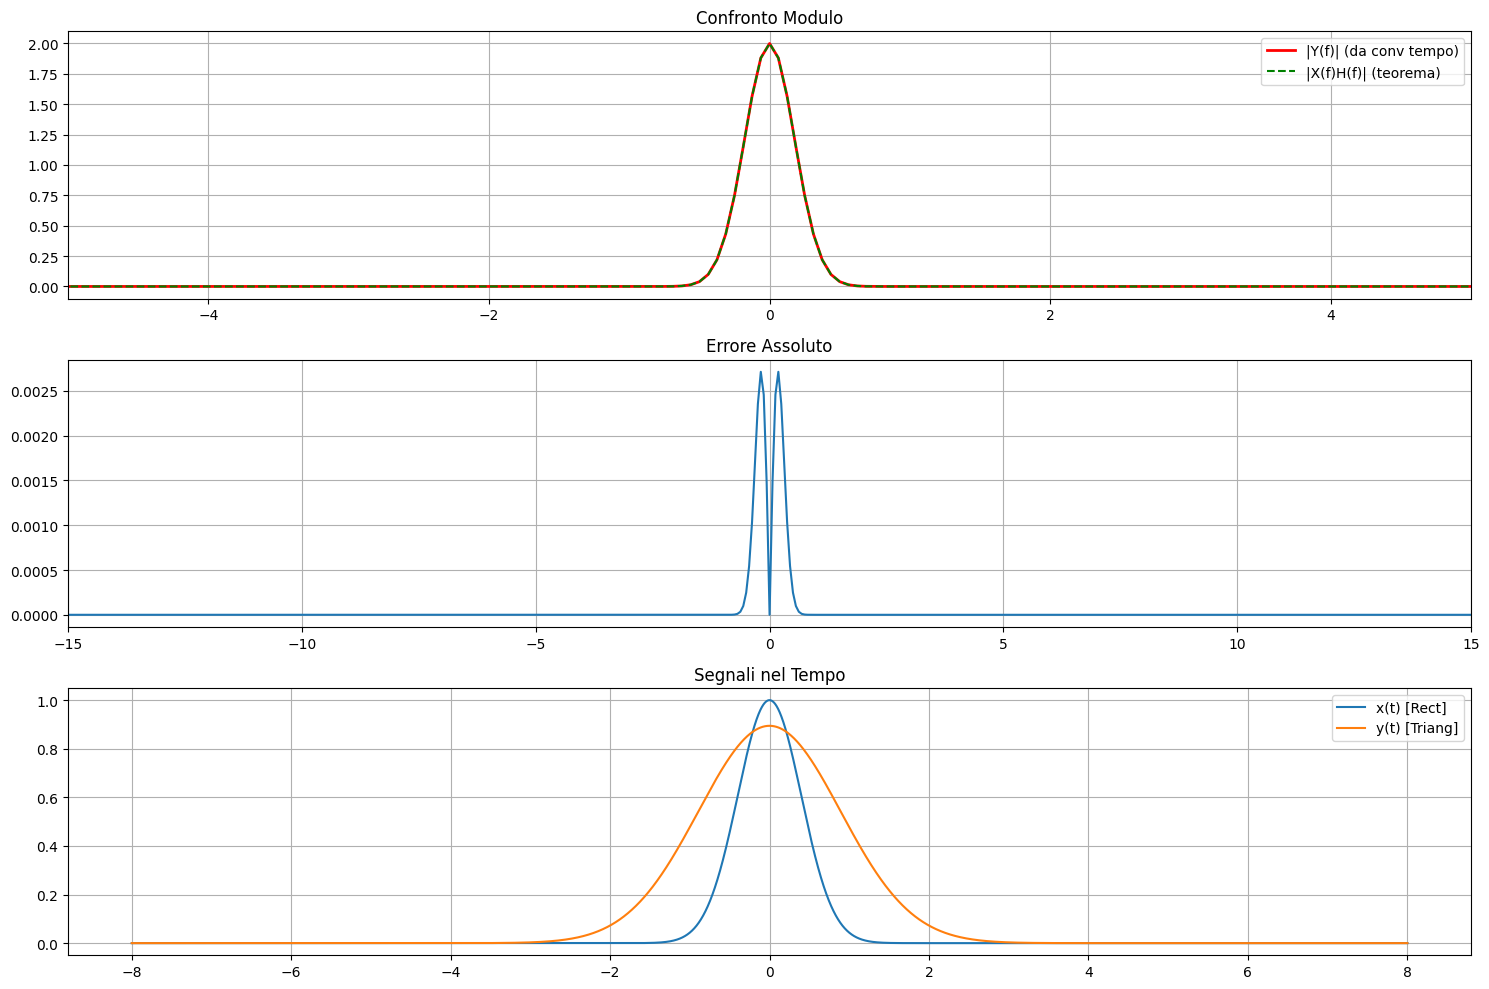

Errore relativo totale: 0.0015853304209959846


In [7]:
dt = 0.002
t = np.arange(-8, 8 + dt, dt)
N = len(t)
T = 1
a = 2

x_t = np.exp(- np.pi * t ** 2)
h_t = np.exp(- np.pi * (t/a) ** 2)

y_t = np.convolve(x_t, h_t, mode="same") * dt

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x_t))) * dt
H = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(h_t))) * dt
freq = np.fft.fftshift(np.fft.fftfreq(N, dt))

Y_pred = X * H # Prodotto delle trasformate
Y = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(y_t))) * dt

fig, ax = plt.subplots(3, 1, figsize=(15, 10))

#modulo
ax[0].plot(freq, np.abs(Y), 'r', label='|Y(f)| (da conv tempo)', linewidth=2)
ax[0].plot(freq, np.abs(Y_pred), 'g--', label='|X(f)H(f)| (teorema)')
ax[0].set_xlim(-5, 5) # Zoom per vedere bene i lobi del Sinc
ax[0].set_title("Confronto Modulo")
ax[0].legend()
ax[0].grid()


#errore
ax[1].plot(freq, np.abs(Y - Y_pred))
ax[1].set_xlim(-15, 15)
ax[1].set_title("Errore Assoluto")
ax[1].grid()

#segnale tempo
ax[2].plot(t, x_t, label='x(t) [Rect]')
ax[2].plot(t, y_t, label='y(t) [Triang]')
ax[2].set_title("Segnali nel Tempo")
ax[2].legend()
ax[2].grid()

plt.tight_layout()
plt.show()

print("Errore relativo totale:", np.linalg.norm(Y - Y_pred)/np.linalg.norm(Y))

Esercizio 8 - Esponenziale * Esponenziale

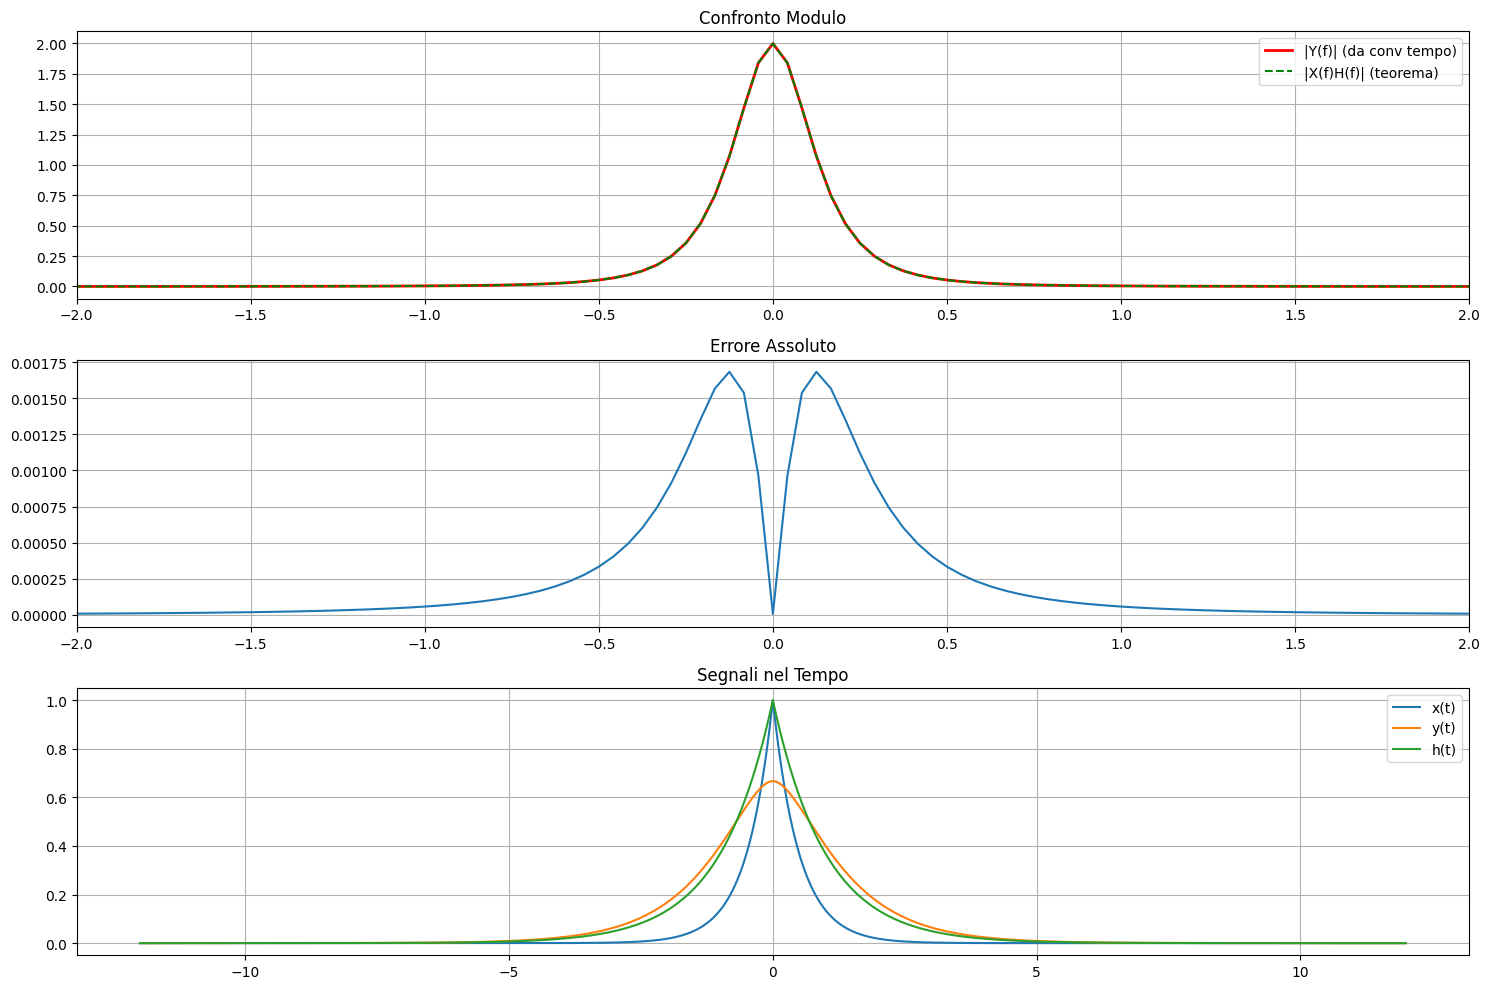

Errore relativo medio: 6.794633726836263e-05


In [8]:
dt = 0.002
t = np.arange(-12, 12 + dt, dt)
N = len(t)

x_t = np.exp(-2 * np.abs(t))
h_t = np.exp(-np.abs(t))

y_t = np.convolve(x_t, h_t, mode="same") * dt

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x_t))) * dt
H = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(h_t))) * dt
freq = np.fft.fftshift(np.fft.fftfreq(N, dt))

Y_pred = X * H # Prodotto delle trasformate

Y = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(y_t))) * dt

#faccio i grafici
fig, ax = plt.subplots(3, 1, figsize=(15, 10))

#modulo
ax[0].plot(freq, np.abs(Y), 'r', label='|Y(f)| (da conv tempo)', linewidth=2)
ax[0].plot(freq, np.abs(Y_pred), 'g--', label='|X(f)H(f)| (teorema)')
ax[0].set_xlim(-2, 2) # Zoom per vedere bene i lobi del Sinc
ax[0].set_title("Confronto Modulo")
ax[0].legend()
ax[0].grid()


#errore
ax[1].plot(freq, np.abs(Y - Y_pred))
ax[1].set_xlim(-2, 2)
ax[1].set_title("Errore Assoluto")
ax[1].grid()

#segnale tempo
ax[2].plot(t, x_t, label='x(t)')
ax[2].plot(t, y_t, label='y(t)')
ax[2].plot(t, h_t, label='h(t)')
ax[2].set_title("Segnali nel Tempo")
ax[2].legend()
ax[2].grid()

plt.tight_layout()
plt.show()

e0 = 1e-5
err = (1 / N) * np.sum(np.abs(np.abs(Y) - np.abs(Y_pred))/ (np.maximum(np.abs(Y_pred), e0)))
print("Errore relativo medio:", err)
#significativa è la scelta di e0

Esercizio 9 - Filtro passa-basso ideale

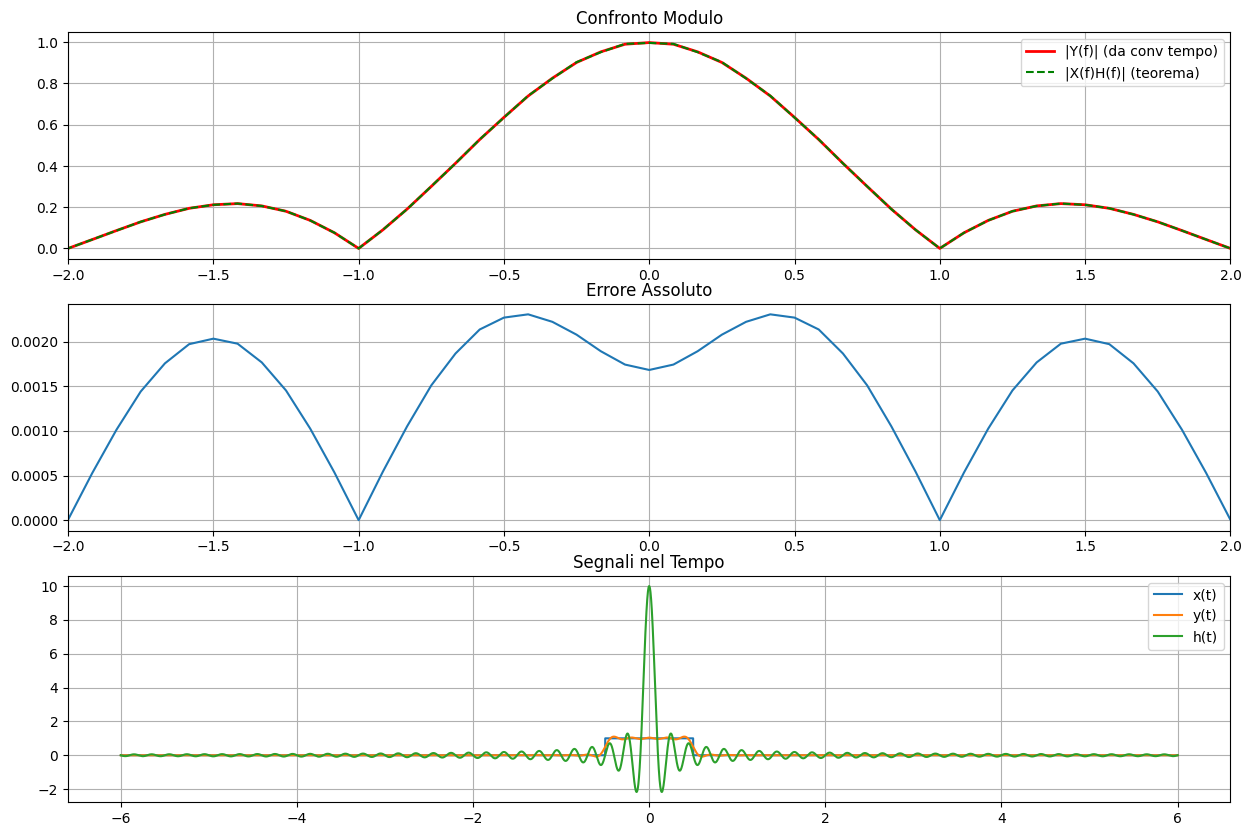

In [9]:
dt = 0.001
T = 1
t = np.arange(-6, 6 + dt, dt)
N = len(t)
B = 5

h_t = 2 * B * np.sinc(2 * B * t)
x_t = np.piecewise(t, [np.abs(t) <= T/2, np.abs(t) > T/2], [1, 0])

y_t = np.convolve(x_t, h_t, mode="same") * dt

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x_t))) * dt
H = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(h_t))) * dt
freq = np.fft.fftshift(np.fft.fftfreq(N, dt))
Y_pred = X * H # Prodotto delle trasformate
Y = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(y_t))) * dt


#faccio i grafici
fig, ax = plt.subplots(3, 1, figsize=(15, 10))

#modulo
ax[0].plot(freq, np.abs(Y), 'r', label='|Y(f)| (da conv tempo)', linewidth=2)
ax[0].plot(freq, np.abs(Y_pred), 'g--', label='|X(f)H(f)| (teorema)')
ax[0].set_xlim(-2, 2) # Zoom per vedere bene i lobi del Sinc
ax[0].set_title("Confronto Modulo")
ax[0].legend()
ax[0].grid()


#errore
ax[1].plot(freq, np.abs(Y - Y_pred))
ax[1].set_xlim(-2, 2)
ax[1].set_title("Errore Assoluto")
ax[1].grid()

#segnale tempo
ax[2].plot(t, x_t, label='x(t)')
ax[2].plot(t, y_t, label='y(t)')
ax[2].plot(t, h_t, label='h(t)')
ax[2].set_title("Segnali nel Tempo")
ax[2].legend()
ax[2].grid()

Esercizio 10 - Verfica della duale

/Users/albertospagnoli/Desktop/marcello/scuola/uni/tirocinio/audio_venv/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/albertospagnoli/Desktop/marcello/scuola/uni/tirocinio/audio_venv/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


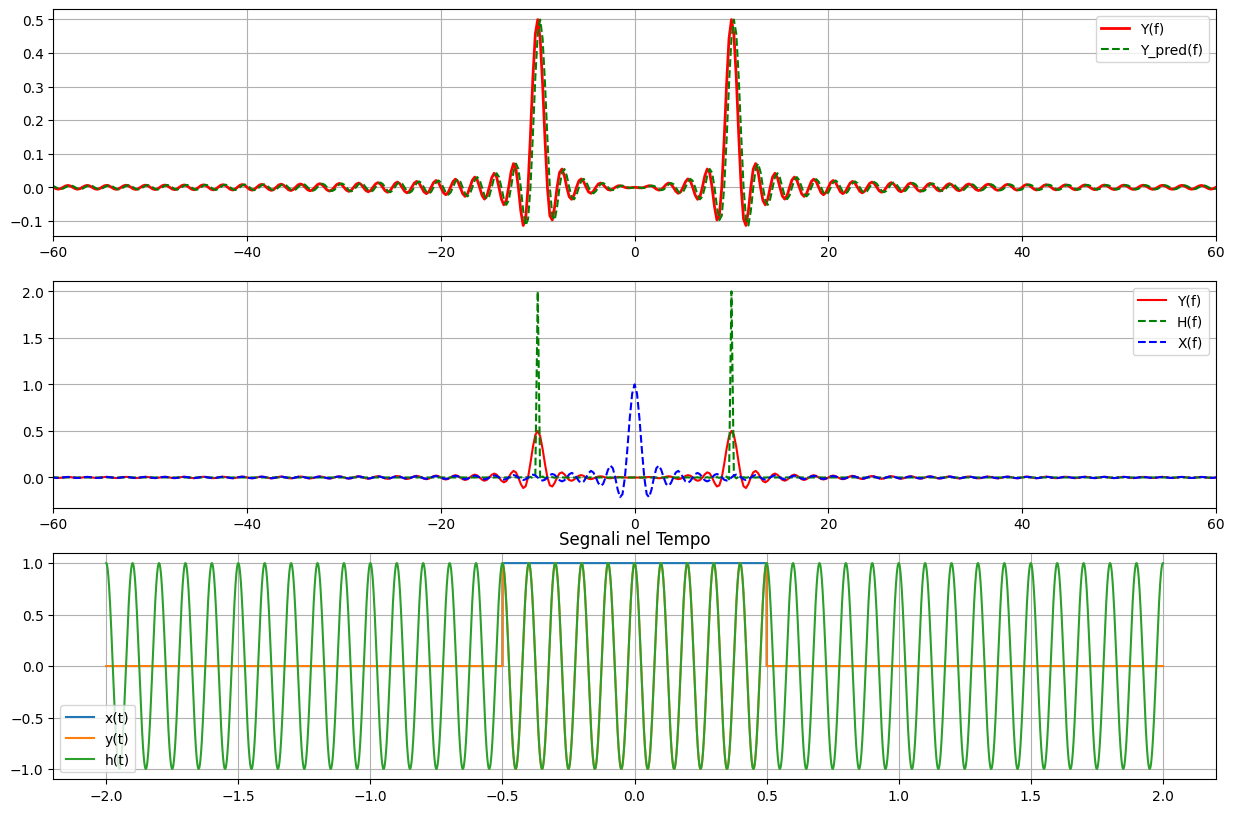

In [10]:
dt = 0.0005
t = np.arange(-2, 2 + dt, dt)
T = 1
N = len(t)
f0 = 10

x_t = np.piecewise(t, [np.abs(t) <= T/2, np.abs(t) > T/2], [1, 0])
h_t = np.cos(2 * np.pi * f0 * t)
y_t = x_t * h_t

Y = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(y_t))) * dt

X = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x_t))) * dt
H = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(h_t))) * dt
freq = np.fft.fftshift(np.fft.fftfreq(N, dt))
df = 1 / (len(t) * dt)
Y_pred = np.convolve(X, H, mode="same") * df

fig, ax = plt.subplots(3, 1, figsize=(15, 10))

#modulo
ax[0].plot(freq, Y, 'r', label='Y(f)', linewidth=2)
ax[0].plot(freq, Y_pred, 'g--', label='Y_pred(f)')
ax[0].set_xlim(-60, 60)
ax[0].legend()
ax[0].grid()


ax[1].plot(freq, Y, "r", label="Y(f)")
ax[1].plot(freq, H, "g", linestyle="--", label="H(f)")
ax[1].plot(freq, X, "b", linestyle="--", label="X(f)")
ax[1].legend()
ax[1].set_xlim(-60, 60)
ax[1].grid()

#segnale tempo
ax[2].plot(t, x_t, label='x(t)')
ax[2].plot(t, y_t, label='y(t)')
ax[2].plot(t, h_t, label='h(t)')
ax[2].set_title("Segnali nel Tempo")
ax[2].legend()
ax[2].grid()